CSV files loaded
Predictions: [1065.027 1073.055 1193.466 ... 1209.521 1040.945 1225.576]
Actual: [ 974.32 1012.35 1044.11 ... 1259.2  1001.13 1195.33]
R² Score: 0.128


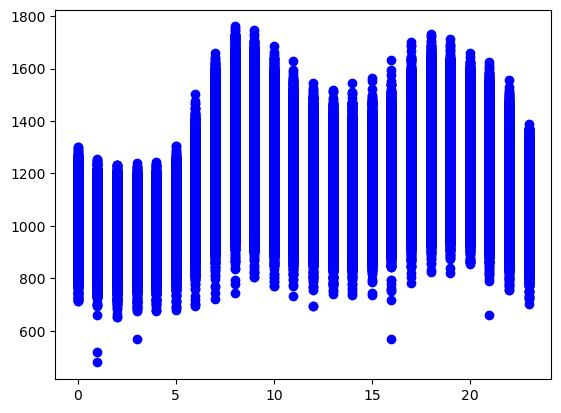

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/TAS_clean.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")

df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y/%m/%d %H:%M")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

X = df['Hour'].values.reshape(-1, 1)
Y = np.array(df['Total Demand'].values)

# Flatten X for plotting
X_flat = X.flatten()


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)


# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
predictions = model.predict(X_test)
print("Predictions:", predictions.round(3))
print("Actual:", y_test.round(3))

r2 = model.score(X_test, y_test)
print("R² Score:", round(r2, 3))

# Plot original data
plt.scatter(X_flat, Y, color='blue', label='Data points')

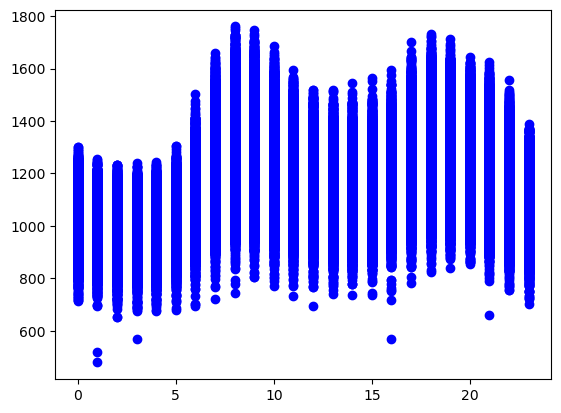

In [9]:
plt.scatter(X_train, y_train, color='blue', label='Data points')

CSV files loaded
  State            Datetime  Total Demand      RRP Precipitation (mm)  \
0  TAS1 2005-05-16 14:00:00    1277.46000   833.33                0.0   
1  TAS1 2005-05-16 14:30:00    1279.19667  4500.00                0.0   
2  TAS1 2005-05-16 15:00:00    1282.52500  4500.00                0.0   
3  TAS1 2005-05-16 15:30:00    1281.69167  8166.67                0.0   
4  TAS1 2005-05-16 16:00:00    1287.23500  4500.00                0.0   

   Air Temp (C)  Humidity (%)  Wind Speed (km/h)  Hour  Year     Day  
0          12.1          68.0                9.4    14  2005  Monday  
1          12.0          72.0                9.4    14  2005  Monday  
2          11.4          78.0                9.4    15  2005  Monday  
3          11.7          76.0                5.4    15  2005  Monday  
4          11.1          81.0                5.4    16  2005  Monday  


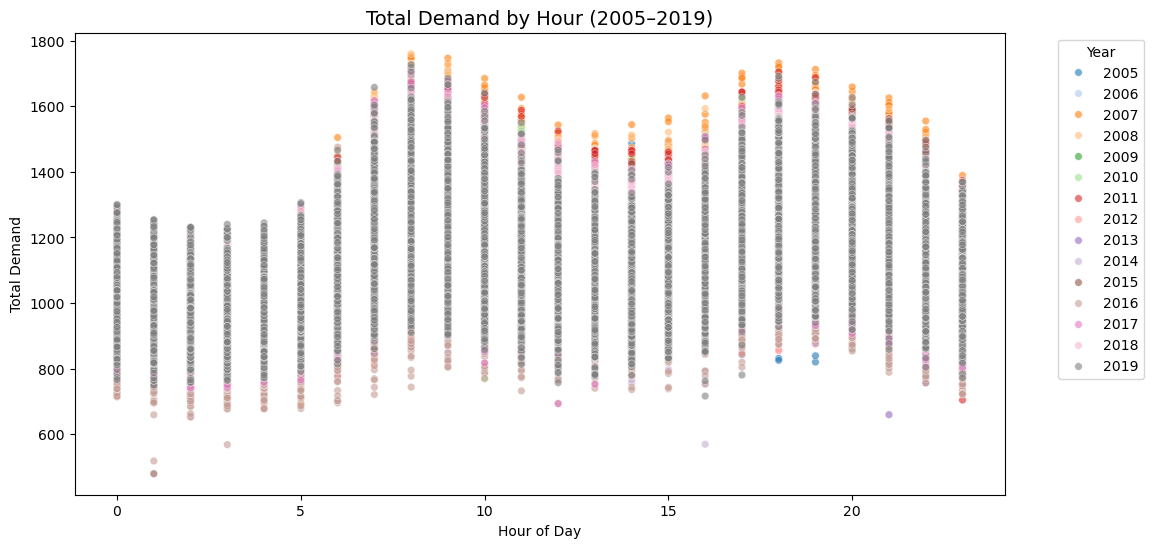

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/TAS_clean.csv")
demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")

df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y/%m/%d %H:%M")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Extract year column
df['Year'] = df['Datetime'].dt.year

df['Day'] = df['Datetime'].dt.day_name()


# Scatter plot with color by year
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x="Hour",
    y="Total Demand",
    hue="Year",            # color by year
    palette="tab20",       # 20 distinct colors (good for many years)
    legend="full",
    s=30,                  # marker size
    alpha=0.6              # transparency
)

plt.title("Total Demand by Hour (2005–2019)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Total Demand")
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside
plt.show()

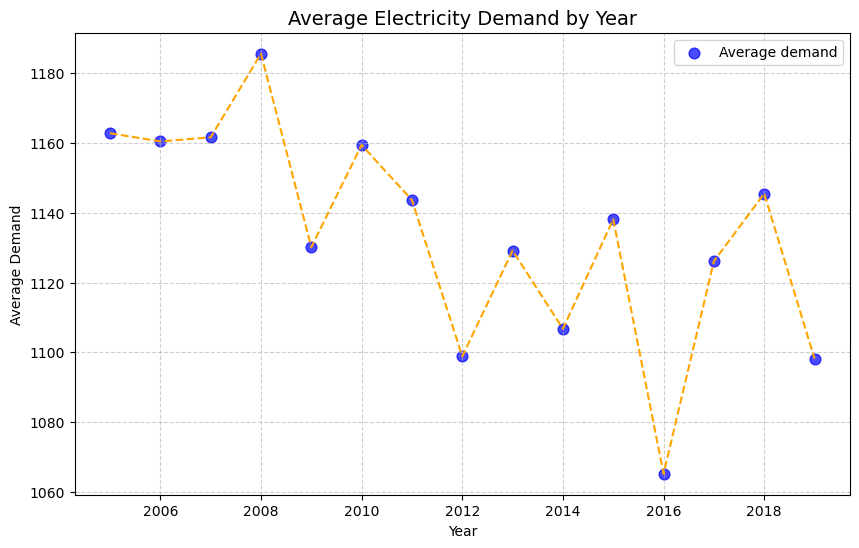

In [28]:
# Extract year column
df['Year'] = df['Datetime'].dt.year

# Compute average demand per year
avg_demand_year = df.groupby('Year')['Total Demand'].mean().reset_index()

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(
    avg_demand_year['Year'], 
    avg_demand_year['Total Demand'], 
    color='blue', 
    s=60, 
    alpha=0.7,
    label="Average demand"
)

plt.plot(avg_demand_year['Year'], avg_demand_year['Total Demand'], color='orange', linestyle='--')  # optional trend line

plt.title("Average Electricity Demand by Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Demand")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

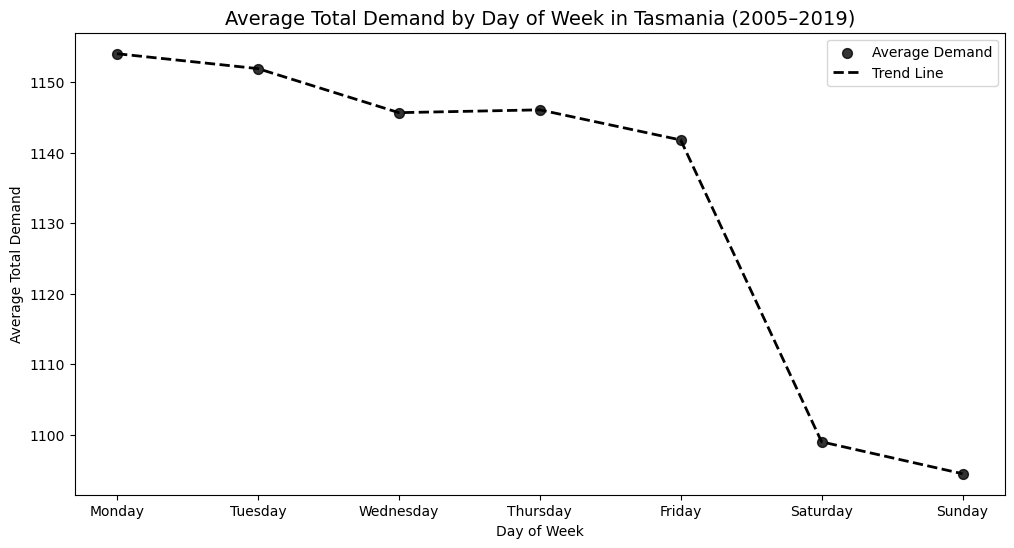

Average Total Demand by Day of Week:
Day
Monday       1154.05
Tuesday      1151.94
Wednesday    1145.69
Thursday     1146.09
Friday       1141.81
Saturday     1098.97
Sunday       1094.45
Name: Total Demand, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import pandas as pd


df['Day'] = df['Datetime'].dt.day_name()
# Define the correct order of days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate average total demand for each day
average_demand_by_day = df.groupby('Day')['Total Demand'].mean()

# Reindex to ensure days are ordered from Monday to Sunday
average_demand_by_day = average_demand_by_day.reindex(day_order)

# Create scatter plot with a connecting line
plt.figure(figsize=(12, 6))
plt.scatter(average_demand_by_day.index, average_demand_by_day.values, 
            color='black', s=50, alpha=0.8, label='Average Demand')
plt.plot(average_demand_by_day.index, average_demand_by_day.values, 
         color='black', linewidth=2, linestyle='--', label='Trend Line')

# Update title and labels
plt.title("Average Total Demand by Day of Week in Tasmania (2005–2019)", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Total Demand")
plt.legend()

# Show plot
plt.show()

# Print the averages
print("Average Total Demand by Day of Week:")
print(average_demand_by_day.round(2))

